In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

## Opgave 1
Antag at et signal $x[n]$ sendes igennem et LTI system med impulsrespons $h[n]$. Outputtet fra systemet betegnes med $y[n]$.

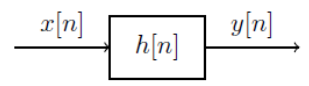



### 1. Opskriv det analytiske udtryk for at beregne $y[n]$ og beregn derefter den numeriske værdi af $y[2]$

svaret er 1 fordi det er numerisk værdi

analytisk udtryk er
$$
y[2] = \sum_{k=-\infty}^{\infty} x[k] h[2-k]
$$

evt skriv helt ud

### 2. Redegør for kausalitets- og stabilitetsegenskaberne af impulsresponset h[n].

Kausalt og stabilt

### 3. To andre impulsresponser er givet ved
$$

$$

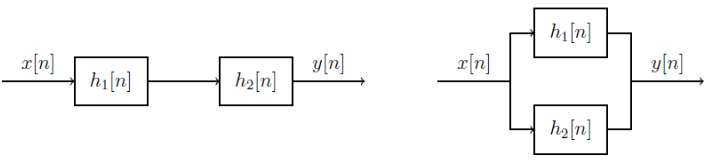

Beregn det samlede impulsrespons i de to tilfælde

Serie
$$
h_s[n] = \{ 8, 2, 31, -19, 56 \}
$$

Parallel
$$
h_p[n] = \{ 6, -2, 15 \}
$$

## Opgave 2
Et LTI-system har nedenstående signal-flow graf

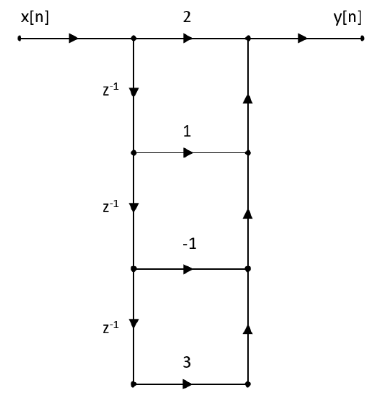

### 1. Opstil differensligningen for filteret og bestem den tilhørende systemfunktion $H(z)$

$$
y[n] = 2x[n] + x[n-1] - x[n-2] + 3x[n-3]
$$
$$
H(z) = \frac{2 + z^{-1} - z^{-2} + 3z^{-3}}{1}
$$

### 2. Beskriv filterets magnitude- og faserespons.

plot

### 3. Antag, at der kan sendes to signaler $x_1[n] = \cos(\frac{\pi}{4} n)$ og $x_2[n] = \cos(\frac{\pi}{8} n)$ igennem filteret. Redegør for, hvilket af de to signaler, der vil have størst amplitude efter filteret.

den laveste bliver forstærket mest, så x_2 altså pi/8

## Opgave 3
Antag, at der ved hjælp af vinduesmetoden skal designes et type-1 lavpas filter med specifikationer
$$
\omega_p = 0.2\pi, \omega_s = 0.3\pi,; A_p = 0.1 dB,; A_s = 40 dB,
$$

og at der skal bruges et Hann vindue.

### 1. Beregn værdien af $M$ og plot lavpasfilterets impulsrespons.

$$
M = 62
$$

### 2. I tilfældet her vil designspecifikationer kunne opnås ved brug af både Hann, Hamming, og Blackman vinduesfunktioner.

figur 10.11 er god

## Opgave 4 
Lad et signal $h[n]$ være givet ved:
$$
h[n] =
\begin{cases}
1 & når \; n = 0 \\
2 & når \; n = 1, \\
1 & når \; n = 2, \\
0 & ellers
\end{cases}
$$

### 1. Beregn $Z$-transformationen $H(z)$, af $h[n]$ og redegør for konvergensen af $H(z)$. 

$h[z]$ kan skrives op som
$$
h[z] = \delta[n] + 2\delta[n-1] + \delta[n-2]
$$

Der kan da laves en z-transformation efter tabel 3.1 og 3.2
$$
H[z] = 1 + 2z^{-1} + z^{-2}
$$

Da $h[z]$ kun bestod af Dirac deltafunktioner med tidsforsinkelse vil det betyde at konvergensen for $H[z]$ vil være 
$$
\text{ROC}: |z| \neq 0
$$

### 2. Skitser grafen for $|H(e^{ j\omega })|$, er $|H(e^{ j\omega })|$ periodisk? 

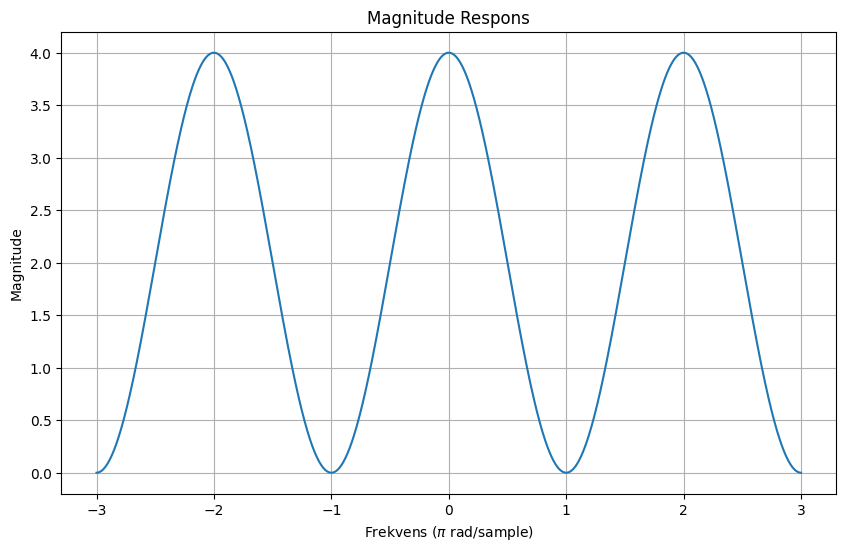

In [15]:
num = [1, 2, 1]
den = [1]
w = np.linspace(-3*np.pi, 3*np.pi, 1000)
_, H = signal.freqz(num, den, worN=w)
plt.figure(figsize=(10, 6))
plt.plot(w / np.pi, np.abs(h))
plt.title('Magnitude Respons')
plt.xlabel('Frekvens ($\pi$ rad/sample)')
plt.ylabel('Magnitude')
plt.grid()

Da $|H(e^{ j\omega })|$ er en kontinuer funktion vil den være periodisk med en periode på $2\pi$, siden $|H(e^{ j\omega })| = |H(e^{ j(\omega + 2\pi) })|$. Dette kan også ses på grafen.

### 3. Et andet signal $x[n]$ er givet ved:
$$
x[n] =
\begin{cases}
(-1)^{n} & når \; n \geq 0, \\
0 & ellers
\end{cases}
$$

Bestem $Z$-transformationen af foldningen $h*x$ mellem $h[n]$ og $x[n]$, og bestem herefter signalet $h*x$.

I stedet for at folde i tidsdomænet kan mange gange i $Z$-domænet ved først at finde $X[z]$. En anden måde at beskrive $x[n]$ er
$$
x[n] = (-1)^{n} u[n]
$$
Dette kan $Z$-transformeres efter tabel 3.1
$$
X[z] = \frac{1}{1 - (-1)z^{-1}} = \frac{1}{1 + z^{-1}}
$$
$Z$-transformationen af foldningen $h*x$ er da givet ved
$$
H(z) \cdot X(z) = \frac{1 + 2z^{-1} + z^{-2}}{1 + z^{-1}}
$$

Foldningen $h*x$ kan nu findes ved invers $Z$-transformation. Dette kan gøres ved først at omskrive til en nemmere form
$$
\begin{align*}
H(z) \cdot X(z) &= \frac{1 + 2z^{-1} + z^{-2}}{1 + z^{-1}}\\
&= \frac{(1 + z^{-1})^{2}}{1 + z^{-1}}\\
&= 1 + z^{-1}
\end{align*}
$$

Signalet $h*x$ bliver dermed
$$
h[n]*x[n] = \delta[n] + \delta[n-1]
$$

### 4. Vi lader nu $x_D[n] := x[n - 3]$. Beregn nu $Z$-transformationen af foldningen $h*x_D$ mellem $h[n]$ og $x_D[n]$, og bestem herefter signalet $h*x_D$.

Da det blot er en tidsforsinkel på $x[n]$ ville det i $Z$-domænet bare være at gange faktoren $z^{-3}$ på. Denne faktor skal også bare ganges på $Z$-transformationen af foldningen, hvilket resulterer i
$$
H(z) \cdot X_D(z) = z^{-3} (1 + z^{-1}) = z^{-3} + z^{-4}
$$

Signalet $h*x_D$ bliver dermed
$$
h[n] * x_D[n] = \delta[n-3] + \delta[n-4]
$$

## Opgave 5
Lad $x_c(t)$ være et analogt signal givet ved: $x_c(t) = \sin(2\pi \cdot 500 Hz \cdot t)$. $x_c(t)$ er input signal til ideel Analog-til-Digital Converter (ADC) med en samplefrekvens $F_s = 800 Hz$. Det samplede diskrete signal efter 
ADC’en er givet ved: $x[n] = x_c(n \cdot T_s)$, hvor $T_s = \frac{1}{F_s}$.

### 1. Redegør for at det samplede signal kan skrives:
$$
x[n] = \cos\left( 2\pi \cdot \left( \frac{3}{8} \cdot n + \frac{2}{8} \right) \right)
$$

Argumenter desuden for at $x[n]$ er periodisk og find fundamentalperioden for $x[n]$.

Det analoge signal samt sampling perioden kan indsættes i det givne diskrete signal

\begin{align*}
x[n] &= x_{c}\left( n \cdot \frac{1}{800Hz} \right)\\
&= \sin\left( 2\pi \cdot 500Hz \cdot n \cdot \frac{1}{800Hz} \right)\\
&= \sin\left( 2\pi \cdot \frac{5}{8} \cdot n \right)\\
&= \cos\left( 2\pi \cdot \frac{5}{8} n - \frac{\pi}{2} \right)\\
&= \cos\left( 2\pi \cdot \left( \frac{5}{8}n - \frac{2}{8} \right) \right)\\
&= \cos\left( 2\pi \cdot \left( - \frac{5}{8}n + \frac{2}{8} \right) \right)
\end{align*}

Her kan det ses at signalet følger formen vist i ligning 4.13, hvor frekvensen $f_0 = -\frac{5}{8}$. Ifølge resultat 4.1.2 er signalet periodisk i frekvensen $f_0$ med en periode på 1, hvilket betyder at et signal med frekvensen $f_0 = -\frac{5}{8} + 1 = \frac{3}{8}$ ville være et identisk signal pga. aliasing. Dette svarer til signalet
$$
x[n] = \cos\left( 2\pi \cdot \left( \frac{3}{8} \cdot n + \frac{2}{8} \right) \right)
$$

hvilket betyder, at det samplede signal godt kan skrives sådan.

Signalet vil være periodisk i tid, hvis der findes et hel $k$, som opfylder $2\pi f_0 N = 2\pi k$, hvor $N$ så ville være fundamentalperioden. Indsættes frekvensen for signalet fås følgende

\begin{align*}
2\pi \frac{3}{8} N &= 2\pi k\\
N &= \frac{8}{3} k\\
N &= 8 \quad k = 3
\end{align*}

Dette svarer til at $x[n]$ er periodisk og har en fundamentalperiode på 8.

### 2. Signalet $x[n]$ rekonstrueres nu med en sample-hold kredsløb, med en samplefrekvens på $800 Hz$. Output af dette kredsløb er signalet $\tilde{x}_c(t)$:
$$
\tilde{x}_{c}(t) = \sum_{n = -\infty}^{\infty} x[n] g_{r}(t - nT_{s}), hvor \; g_{r}(t) = 
\begin{cases}
1 & 0 \leq t < T_{s}, \\
0 & ellers
\end{cases} 
$$

Skitser i det samme koordinatsystem graferne for de 3 signaler: $x(t)$, $\tilde{x}_{c}(t)$, og $e(t)$, idet vi lader $e(t) = x(t) - \tilde{x}_{c}(t)$.

Det vides at $g_r(t)$ kun vil være 1, hvis $nT_s$ ikke får t under 0 eller over $T_s$. Dette kan betegnes som 
$$
g_r(t - nT_s)=1, \quad nT_s \leq t < nT_s + T_s
$$

Her vil det også gælde at $\tilde{x}_c(t) = x[n]$. Når $x[n]$ skal indsættes skal $n$ opskrives som udtryk af $t$. Hvert $n$ sample kan beskrives som $\frac{t}{T_{s}}$ rundet ned, hvilket vil svare til at "holde" på en sampled værdi i $\frac{1}{800}$ sekunder. Dette plottes i python således

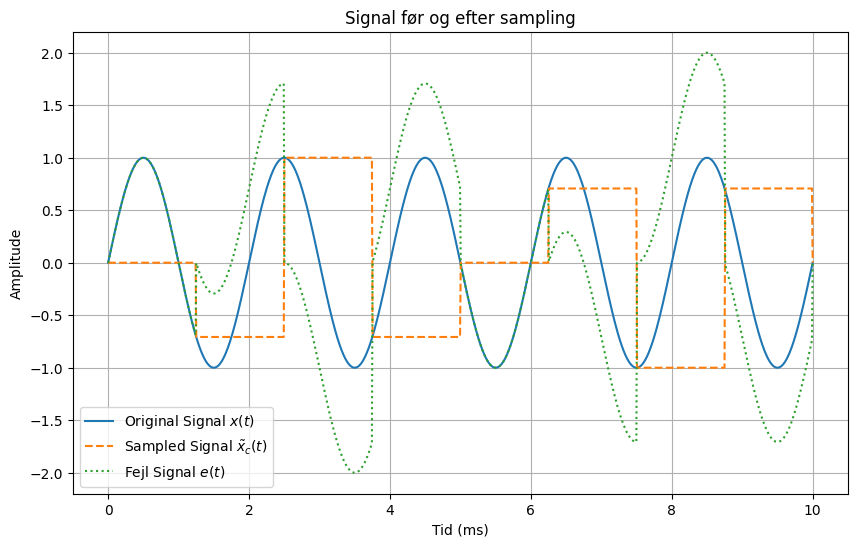

In [39]:
fs = 800
Ts = 1 / fs
t = np.linspace(0, 0.01, 1000)
tms = t*1000
x = np.sin(2 * np.pi * 500 * t)
xtilde = np.cos(2 * np.pi * (3/8 * np.floor(t / Ts) + 2/8))
e = x - xtilde
plt.figure(figsize=(10, 6))
plt.plot(tms, x, label='Original Signal $x(t)$')
plt.plot(tms, xtilde, label='Sampled Signal $\\tilde{x}_c(t)$', linestyle='--')
plt.plot(tms, e, label='Fejl Signal $e(t)$', linestyle=':')
plt.title('Signal før og efter sampling')
plt.xlabel('Tid (ms)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()

### 3. Forklar, hvordan man ved at vælge et andet $g_r(t)$ kan opnå en bedre rekonstruktion. 

Signalet med nuværende $g_r(t)$ er meget diskontinuær. Bruger man andre filtre ville man kunne bløde det ud og gøre rekonstruktionen bedre. 

sinc ville være bedre og det almindelige valg